# IMDb Sentiment Analysis using RNN

This notebook builds a Recurrent Neural Network model to classify IMDb movie reviews as **positive** or **negative**. It includes loading data, preprocessing, model building, training, evaluation, prediction, and visualization.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

## 2. Load IMDb Dataset

The IMDb dataset is already available inside Keras. Reviews are stored as integer sequences, where each integer represents a word.

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))
print('Example review length:', len(X_train[0]))

Training samples: 25000
Testing samples : 25000
Example review length: 218


## 3. Pad Sequences

RNN models need inputs with the same length. So all reviews are padded or trimmed to 200 words.

In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post')

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

X_train shape: (25000, 200)
X_test shape : (25000, 200)


## 4. Build the RNN Model

Important: `Input shape` is added in the Embedding layer so the model is built correctly and `model.summary()` shows the parameters.

In [8]:
model = Sequential()

model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_shape=(max_length,)
))

model.add(SimpleRNN(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the Model

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 6. Train the Model

`EarlyStopping` stops training when validation loss does not improve. This avoids unnecessary training and overfitting.

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.6080 - loss: 0.6577 - val_accuracy: 0.5186 - val_loss: 0.6995
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.6987 - loss: 0.5485 - val_accuracy: 0.4994 - val_loss: 0.7589
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.7355 - loss: 0.4603 - val_accuracy: 0.5164 - val_loss: 0.8185
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.7770 - loss: 0.3910 - val_accuracy: 0.5130 - val_loss: 0.8553
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8034 - loss: 0.3570 - val_accuracy: 0.5170 - val_loss: 0.9358
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.8213 - loss: 0.3250 - val_accuracy: 0.5056 - val_loss: 0.9749
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.8411 - loss: 0.3107 - val_accuracy: 0.5088 - val_loss: 1.0175
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.8479 - loss: 0.3067 - 

## 7. Evaluate the Model

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print('Test Loss    :', round(test_loss, 4))
print('Test Accuracy:', round(test_accuracy, 4))

Test Loss    : 1.0126
Test Accuracy: 0.5074


## 8. Make Predictions

In [14]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype('int32').flatten()

print('First 10 predicted labels:', y_pred[:10])
print('First 10 actual labels   :', y_test[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step
First 10 predicted labels: [1 1 1 0 1 0 1 1 0 1]
First 10 actual labels   : [0 1 1 0 1 1 1 0 0 1]


## 9. Classification Metrics

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', round(accuracy, 4))
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.5074
Classification Report:
              precision    recall  f1-score   support

    Negative       0.51      0.49      0.50     12500
    Positive       0.51      0.53      0.52     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.51     25000
weighted avg       0.51      0.51      0.51     25000



## 10. Confusion Matrix

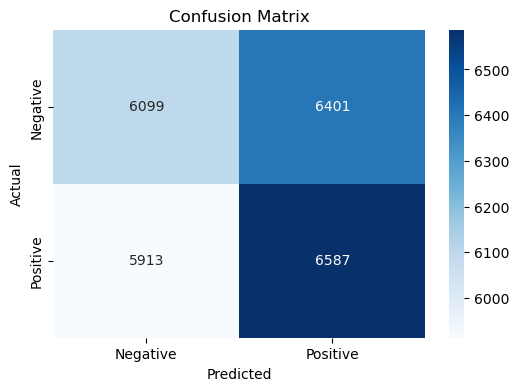

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 11. Training and Validation Accuracy

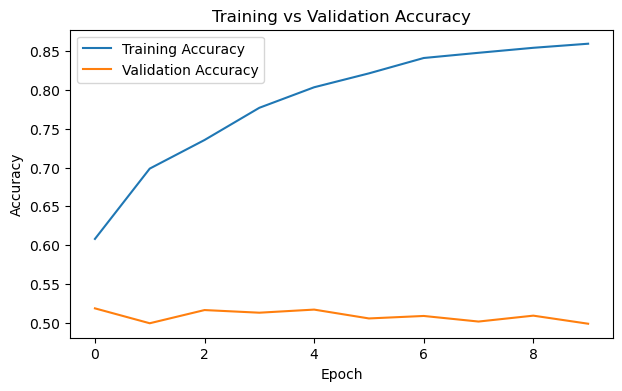

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

## 12. Training and Validation Loss

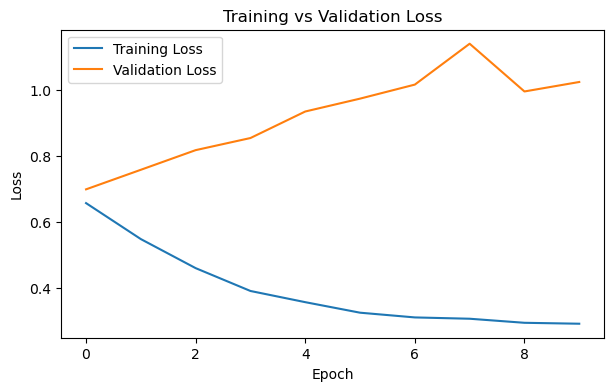

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 13. Test with a Custom Review

In [20]:
word_index = imdb.get_word_index()

def encode_review(text, max_length=200):
    words = text.lower().split()
    encoded = []
    for word in words:
        index = word_index.get(word)
        if index is not None and index < vocab_size:
            encoded.append(index + 3)
        else:
            encoded.append(2)  # unknown word
    padded = pad_sequences([encoded], maxlen=max_length, padding='post', truncating='post')
    return padded

def predict_sentiment(review):
    encoded_review = encode_review(review)
    probability = model.predict(encoded_review, verbose=0)[0][0]
    sentiment = 'Positive' if probability > 0.5 else 'Negative'
    print('Review:', review)
    print('Sentiment:', sentiment)
    print('Positive probability:', round(float(probability), 4))

sample_review = 'This movie was excellent with great acting and a wonderful story'
predict_sentiment(sample_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Review: This movie was excellent with great acting and a wonderful story
Sentiment: Positive
Positive probability: 0.5808


## Conclusion

The RNN model learns the sequential relationship between words in IMDb reviews and classifies each review as positive or negative. The model performance is evaluated using accuracy, precision, recall, F1-score, and confusion matrix. For higher accuracy, an LSTM or GRU model can be used instead of SimpleRNN.